In [1]:
from AutoencoderAPI.recurrentTriplet import recurrentTriplet
from AutoencoderAPI.fileBatch import fileBatch
from AutoencoderAPI.fileBatchtSNE import fileBatchtSNE
from AutoencoderAPI.encoderStack import encoderStack
from AutoencoderAPI.transformer import transformer
from AutoencoderAPI.utils.plot import load_run_results, load_sweep_results
from AutoencoderAPI.sweep import sweep

### Configuration

#### Triplet config

In [2]:
run_config_Triplet = {
'files' : {
        'dataset'                  : "Datasets/SNSPD/Paderborn/data",
        'path_save'                : 'AutoencoderLog/',
        'input_dimension'          : 30_000, 
        'folder_type'              : 'npy'
        },
'network' : {
        'network_type'             : 'generic',
        'activation_list'          : ['Mish', 'CELU', 'LeakyReLU', 'CELU', 'Mish'],
        'layer_list'               : [100, 10, 1, 10, 100],
        'layer_type'               : 'Linear',
        'bw_cst'                   : [0.005]
        },
'train' : {
        'optimizer'                : 'Adam',
        'alpha'                    : 0.002,    #0.002
        'epochs_MSE'               : 3,
        'epochs_triplet'           : 5,
        'skip_elements'            : 1,
        'interval'                 : [3000,6500],
        'learning_rate_MSE'        : 1e-3,
        'learning_rate_triplet'    : 1e-6
        }
}

#### MSE config

In [3]:
run_config_MSE = {
'files' : {
        'dataset'                  : "Datasets/TES/NIST train",
        'path_save'                : 'AutoencoderLog/',
        'input_dimension'          : 8192,
        'folder_type'              : None
        },
'network' : {
        'network_type'             : 'generic',
        'activation_list'          : ['Mish', 'CELU', 'Tanh', 'CELU', 'Mish'],
        'layer_list'               : [100, 100, 1, 100, 100],
        'layer_type'               : 'Linear'
        },
'train' : {
        'optimizer'                : 'Adam',
        'criterion'                : 'MSELoss', #MSELoss
        'k-fold'                   : 2,
        'batch_number'             : 3,
        'epochs'                   : 4,
        'skip_elements'            : 1,
        'interval'                 : [0,270],
        'learning_rate'            : 1e-6
        }
}

In [4]:
run_config_MSE = {
'files' : {
        'dataset'                  : "Datasets/SNSPD/Paderborn/data train",
        'path_save'                : 'AutoencoderLog/',
        'input_dimension'          : 30_000,
        'folder_type'              : 'npy'
        },
'network' : {
        'network_type'             : 'dropout',
        'activation_list'          : ['CELU', 'Mish', 'Tanh', 'Mish', 'CELU'],#['Hardshrink', 'LeakyReLU', 'PReLU', 'LeakyReLU', 'Hardshrink']
        'layer_list'               : [50, 50, 1, 50, 50],
        'layer_type'               : 'Linear'
        },
'train' : {
        'optimizer'                : 'Adam',
        'criterion'                : 'MSELoss',#'MSELoss', 
        'k-fold'                   : 2,
        'batch_number'             : 4,
        'epochs'                   : 5,
        'skip_elements'            : 1,
        'interval'                 : [3250,4500],#[3250,4500],
        'learning_rate'            : 1e-6
        },
'dB' : 15.99
}

#### Transformer config

In [5]:
run_config_Transformer = {
'files' : {
        'dataset'                  : "Datasets/NIST (250)",
        'path_save'                : 'AutoencoderLog/',
        'input_dimension'          : 250
        },
'network' : {
        'nhead'                    : 250,
        'dropout'                  : 0.1,
        'sequence_len'             : 1       
        },
'train' : {
        'optimizer'                : 'Adam',
        'criterion'                : 'MSELoss',
        'epochs'                   : 6,
        'learning_rate'            : 1e-6
        }
}

### Run

In [6]:
#func = recurrentTriplet()
func = fileBatch()
#func = fileBatchtSNE()
#func = transformer()
#func.run(run_config_MSE)
"""
es = encoderStack()
es.train(run_config_MSE,
        stack_name = 'stack',
        step_number = 3,
        flip = False,
        bw = 0.025)
"""

"\nes = encoderStack()\nes.train(run_config_MSE,\n        stack_name = 'stack',\n        step_number = 3,\n        flip = False,\n        bw = 0.025)\n"

### Sweep

In [7]:
sweep_config = {
    'sweep_name'               : 'grid-search-SNSPD param 4',
    'search_param'             : [('train','epochs'),
                                  ('train','learning_rate')],
                               # [('network','activation_possibilty'), # 
                               #  ('network','layer_size_possibility')],   #
    'epochs'                   : [4,5,6], #
    'learning_rate'            : [1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7],
    'alpha'                    : [1e2, 1e1, 1e-0, 1e-1, 1e-2, 1e-3, 1e-4],
    'activation_possibilty'    : ['ReLU', 'Sigmoid', 'CELU', 'Softmax', 'Softmin', 'Hardshrink', 
                                    'LeakyReLU', 'ELU', 'LogSigmoid', 'PReLU', 'GELU', 'SiLU', 
                                    'Mish', 'Softplus', 'Softsign', 'Tanh'],
    'layer_size_possibility'   : [5,10,20,30,50]
}

In [8]:
exp = sweep()
#exp.random_search(run_config_MSE, sweep_config, 20)
#exp.grid_search(run_config_MSE, sweep_config)

### Load Run

{'network_type': 'dropout', 'activation_list': ['CELU', 'Mish', 'Tanh', 'Mish', 'CELU'], 'layer_list': [50, 50, 1, 50, 50], 'layer_type': 'Linear'}


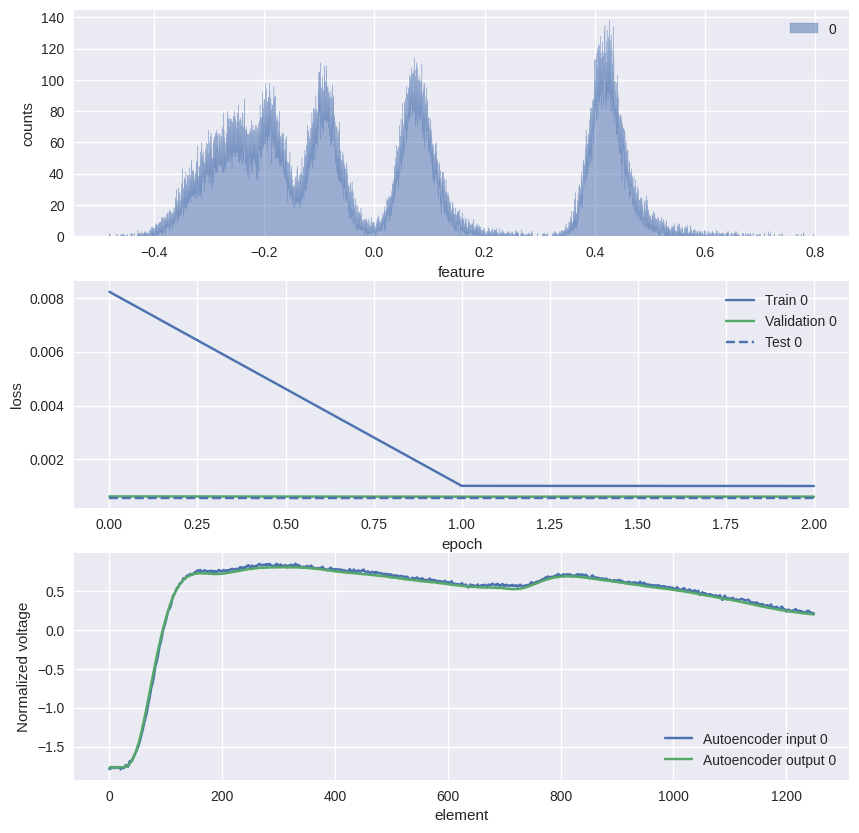

{'network_type': 'dropout', 'activation_list': ['CELU', 'Mish', 'Tanh', 'Mish', 'CELU'], 'layer_list': [50, 50, 1, 50, 50], 'layer_type': 'Linear'}


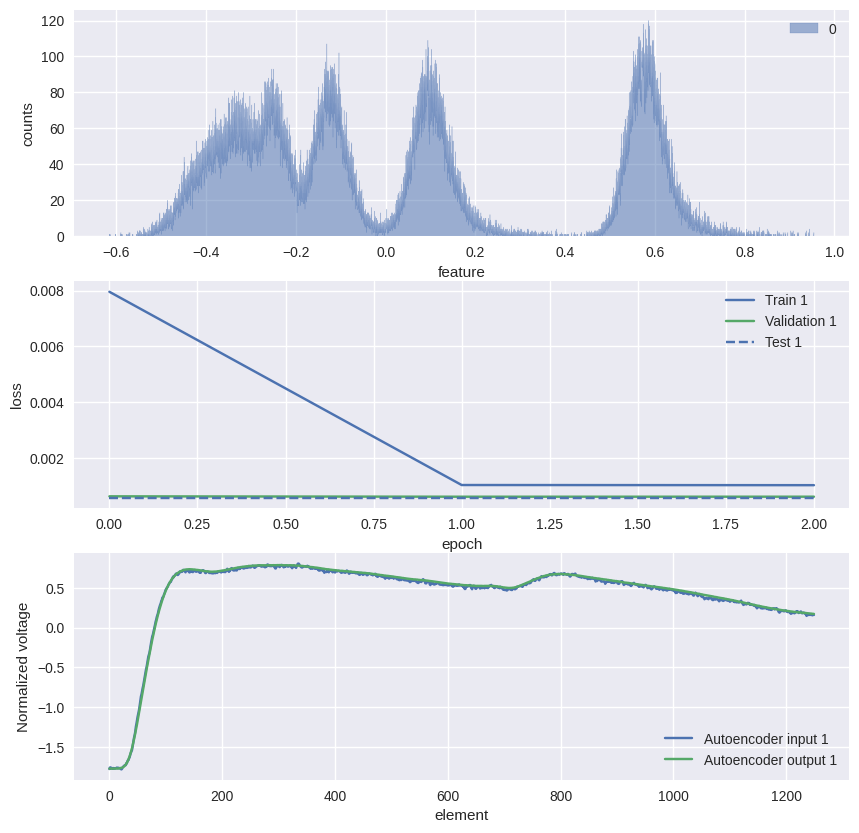

In [9]:
load_run_results("AutoencoderLog/grid-search-SNSPD param 3/run 04", bw=[0.1], clustering=False, print_network=True, print_train=False)

### Load Sweep

min :  0.0005897392720093434
learning_rate :  1e-05
epochs :  5
[0.003350113182105107, 0.002396380717724528, 0.001805643755212038, 0.0006140882556859382, 0.0006564715631703842, 0.0013886542630659469, 0.003381936086374235, 0.0033912270415192656, 0.000880139672293599, 0.0005897392720093434, 0.0, 0.0]


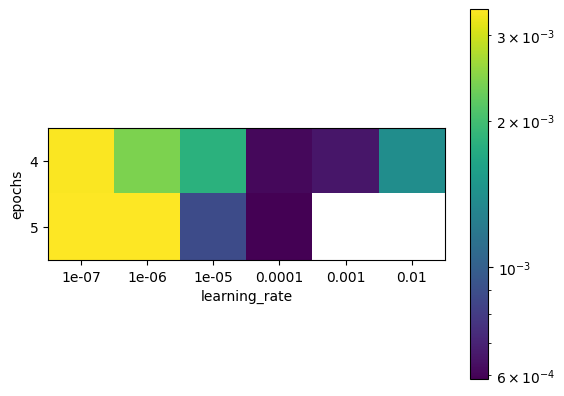

In [11]:
load_sweep_results("grid-search-SNSPD param 4", ["learning_rate", "epochs"])